## Import delivery feature table made in PostgreSQL, inspect general features

In [1]:
import pandas as pd

df = pd.read_csv("delivery_features.csv")
df.head()

,order_id,customer_state,review_score,num_items,total_order_value,num_sellers,delivery_days,delay_days,delay_category
0,e481f51cbdc54678b7cc49136f2d6af7,SP,4.0,1,38.71,1,8,-7,on_time
1,47770eb9100c2d0c44946d9cf07ec65d,GO,5.0,1,179.12,1,9,-17,on_time
2,949d5b44dbf5de918fe9c16f97b45f8a,RN,5.0,1,72.20,1,13,-12,on_time
3,a4591c265e18cb1dcee52889e2d8acc3,PR,4.0,1,175.26,1,16,-5,on_time
4,76c6e866289321a7c93b82b54852dc33,RS,1.0,1,35.95,1,9,-31,on_time


In [2]:
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97005 entries, 0 to 97004
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   order_id           97005 non-null  object 
 1   customer_state     97005 non-null  object 
 2   review_score       96359 non-null  float64
 3   num_items          97005 non-null  int64  
 4   total_order_value  97005 non-null  float64
 5   num_sellers        97005 non-null  int64  
 6   delivery_days      97005 non-null  int64  
 7   delay_days         97005 non-null  int64  
 8   delay_category     97005 non-null  object 
dtypes: float64(2), int64(4), object(3)
memory usage: 6.7+ MB


(97005, 9)

## Find and drop duplicated rows

In [3]:
df.duplicated().sum() 

np.int64(340)

In [4]:
df[df.duplicated(keep=False)].sort_values('order_id').head(20) # Show how the same order appears in two different rows

,order_id,customer_state,review_score,num_items,total_order_value,num_sellers,delivery_days,delay_days,delay_category
92976,0035246a40f520710769010f752e7507,SP,5.0,1,99.11,1,11,-8,on_time
92975,0035246a40f520710769010f752e7507,SP,5.0,1,99.11,1,11,-8,on_time
94443,0176a6846bcb3b0d3aa3116a9a768597,SP,5.0,1,53.68,1,4,-16,on_time
94442,0176a6846bcb3b0d3aa3116a9a768597,SP,5.0,1,53.68,1,4,-16,on_time
80370,02e0b68852217f5715fb9cc885829454,SP,4.0,1,68.89,1,6,-18,on_time
80371,02e0b68852217f5715fb9cc885829454,SP,4.0,1,68.89,1,6,-18,on_time
3668,03515a836bb855b03f7df9dee520a8fc,RS,5.0,1,106.38,1,17,-23,on_time
3667,03515a836bb855b03f7df9dee520a8fc,RS,5.0,1,106.38,1,17,-23,on_time
5994,03c939fd7fd3b38f8485a0f95798f1f6,RJ,3.0,1,42.11,1,22,-13,on_time
5996,03c939fd7fd3b38f8485a0f95798f1f6,RJ,3.0,1,42.11,1,22,-13,on_time


In [5]:
df_clean = df.drop_duplicates(subset='order_id')

In [6]:
df_clean['order_id'].nunique(), len(df_clean) # Observe how 97005 changed to 96476

(96476, 96476)

In [7]:
df['order_id'].value_counts().value_counts().sort_index() # "2 521" means 521 orders had one duplicate, "3 4" means 4 orders had two duplicates

# So, 521 duplicates + 8 duplicates = 529 total duplicates 
# It checks out that 97005 - 96476 = 529

count
1    95951
2      521
3        4
Name: count, dtype: int64

## Find and drop null values for review score

In [8]:
df_clean.isnull().sum()

order_id               0
customer_state         0
review_score         646
num_items              0
total_order_value      0
num_sellers            0
delivery_days          0
delay_days             0
delay_category         0
dtype: int64

In [9]:
df_final = df_clean.dropna(subset=['review_score'])

In [10]:
len(df_final)

95830

In [11]:
df_final.isnull().sum()

order_id             0
customer_state       0
review_score         0
num_items            0
total_order_value    0
num_sellers          0
delivery_days        0
delay_days           0
delay_category       0
dtype: int64

## Create delay days and order value segments

In [12]:
def delay_bucket(x):
    if x <= 0:
        return "early"
    elif x <= 2:
        return "1-2 days late"
    elif x <= 7:
        return "3-7 days late"
    else:
        return "7+ days late"

df_final = df_final.copy()

df_final['delay_bucket'] = df_final['delay_days'].apply(delay_bucket)

In [13]:
def value_bucket(x):
    if x < 50:
        return "low"
    elif x< 150:
        return "medium"
    else:
        return "high"

df_final = df_final.copy()

df_final['value_bucket'] = df_final['total_order_value'].apply(value_bucket)

## Segment delay days, order value, and number of sellers by review score

In [14]:
df_final.groupby('delay_bucket')['review_score'].mean()

delay_bucket
1-2 days late    3.513274
3-7 days late    2.232620
7+ days late     1.699137
early            4.290303
Name: review_score, dtype: float64

In [15]:
df_final.groupby('value_bucket')['review_score'].mean()

value_bucket
high      4.067152
low       4.248901
medium    4.181324
Name: review_score, dtype: float64

In [16]:
df_final.groupby('num_sellers')['review_score'].mean()

num_sellers
1    4.173291
2    2.881864
3    2.351852
4    1.000000
5    1.000000
Name: review_score, dtype: float64

## Histogram of delay days and box plot of delay days by review score 

In [17]:
df_final.describe()

,review_score,num_items,total_order_value,num_sellers,delivery_days,delay_days
count,95830.000000,95830.000000,95830.000000,95830.000000,95830.000000,95830.000000
mean,4.155901,1.141281,159.560920,1.013847,12.052760,-10.994021
std,1.284812,0.534097,217.488378,0.123374,9.466426,9.952409
min,1.000000,1.000000,9.590000,1.000000,0.000000,-146.000000
25%,4.000000,1.000000,61.800000,1.000000,6.000000,-16.000000
50%,5.000000,1.000000,105.280000,1.000000,10.000000,-11.000000
75%,5.000000,1.000000,176.160000,1.000000,15.000000,-6.000000
max,5.000000,21.000000,13664.080000,5.000000,208.000000,188.000000


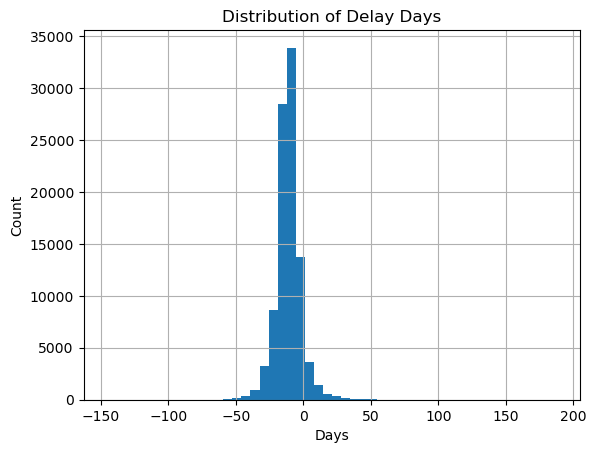

In [18]:

import matplotlib.pyplot as plt

df_final['delay_days'].hist(bins=50)
plt.title("Distribution of Delay Days")
plt.xlabel("Days")
plt.ylabel("Count")
plt.show()

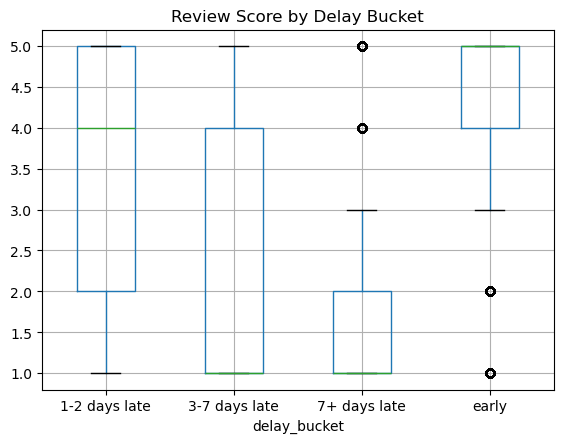

In [19]:
df_final.boxplot(column='review_score', by='delay_bucket')
plt.title("Review Score by Delay Bucket")
plt.suptitle("")
plt.show()

# Most orders are early; very few orders are late 

In [20]:
df_final.groupby('delay_bucket')['review_score'].describe()

# Showing a tighter spread indicating low variability, early deliveries lead to predictably good reviews (5+ stars). 
# 1-2 day late deliveries don't indicate any meaningful effect on review scores, however the variability in customer satisfaction is higher.
# 1-2 day late deliveries probably don't have that much an impact on whether customers submit a bad review. 
# 3-7 day late deliveries heavily impact review scores. The wider spread of the box plot indicates unpredictable customer satisfaction. 
# Showing a tighter spread indicating low variability, 7+ day late deliveries lead to predictably bad reviews (1 star). 


,count,mean,std,min,25%,50%,75%,max
delay_bucket,,,,,,,,
1-2 days late,1356.0,3.513274,1.496555,1.0,2.0,4.0,5.0,5.0
3-7 days late,2244.0,2.232620,1.565991,1.0,1.0,1.0,4.0,5.0
7+ days late,2782.0,1.699137,1.232891,1.0,1.0,1.0,2.0,5.0
early,89448.0,4.290303,1.149344,1.0,4.0,5.0,5.0,5.0


In [21]:
df_final.groupby('delay_bucket')['review_score'].std()

delay_bucket
1-2 days late    1.496555
3-7 days late    1.565991
7+ days late     1.232891
early            1.149344
Name: review_score, dtype: float64

## Export cleaned Olist dataset

In [22]:
df_final.to_csv("final_delivery_dataset.csv", index=False)